# Figure S SHAP — Plots
Loads pre-computed SHAP artefacts from `OUT_DIR` and produces all Figure S panels.
Run `Generate_data_Figure_S_SHAP.ipynb` first to create those artefacts.

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from conus_biomass import dir_info
from conus_biomass.make_figures import figure_settings

In [2]:
OUT_DIR = "../figure_data/figure_S_SHAP/"

## Load SHAP artefacts

In [3]:
shap_values_init = joblib.load(OUT_DIR + "shap_values_init.pkl")
shap_values_burned = joblib.load(OUT_DIR + "shap_values_burned.pkl")
shap_values_undisturbed = joblib.load(OUT_DIR + "shap_values_undisturbed.pkl")

X_test_sample_init = pd.read_pickle(OUT_DIR + "X_test_sample_init.pkl")
X_test_sample_burned = pd.read_pickle(OUT_DIR + "X_test_sample_burned.pkl")
X_test_sample_undisturbed = pd.read_pickle(OUT_DIR + "X_test_sample_undisturbed.pkl")

## Helper: sort features by mean |SHAP|

In [4]:
def get_sorted_features(shap_values, max_display=6):
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
    sorted_idx = np.argsort(mean_abs_shap)[::-1]
    feature_names = np.array(shap_values.feature_names)
    return feature_names[sorted_idx[:max_display]]


features_init = get_sorted_features(shap_values_init)
features_burned = get_sorted_features(shap_values_burned)
features_undisturbed = get_sorted_features(shap_values_undisturbed)

print("Init features:", features_init)
print("Burned features:", features_burned)
print("Undisturbed features:", features_undisturbed)

Init features: ['% Live canopy cover' 'Stand age' 'Wet season mean precipitation'
 'Coldest season min temperature' 'Elevation' 'Mean precipitation']
Burned features: ['Initial biomass' '% Live canopy cover change'
 'Coldest season min temperature' 'Mean temperature' 'Ecosection'
 'Mean precipitation']
Undisturbed features: ['Initial biomass' 'Mean precipitation'
 '% Live canopy cover change / year' 'Mean temperature'
 'Coldest season min temperature' 'Ecosection']


## Figure S-A: SHAP bar charts

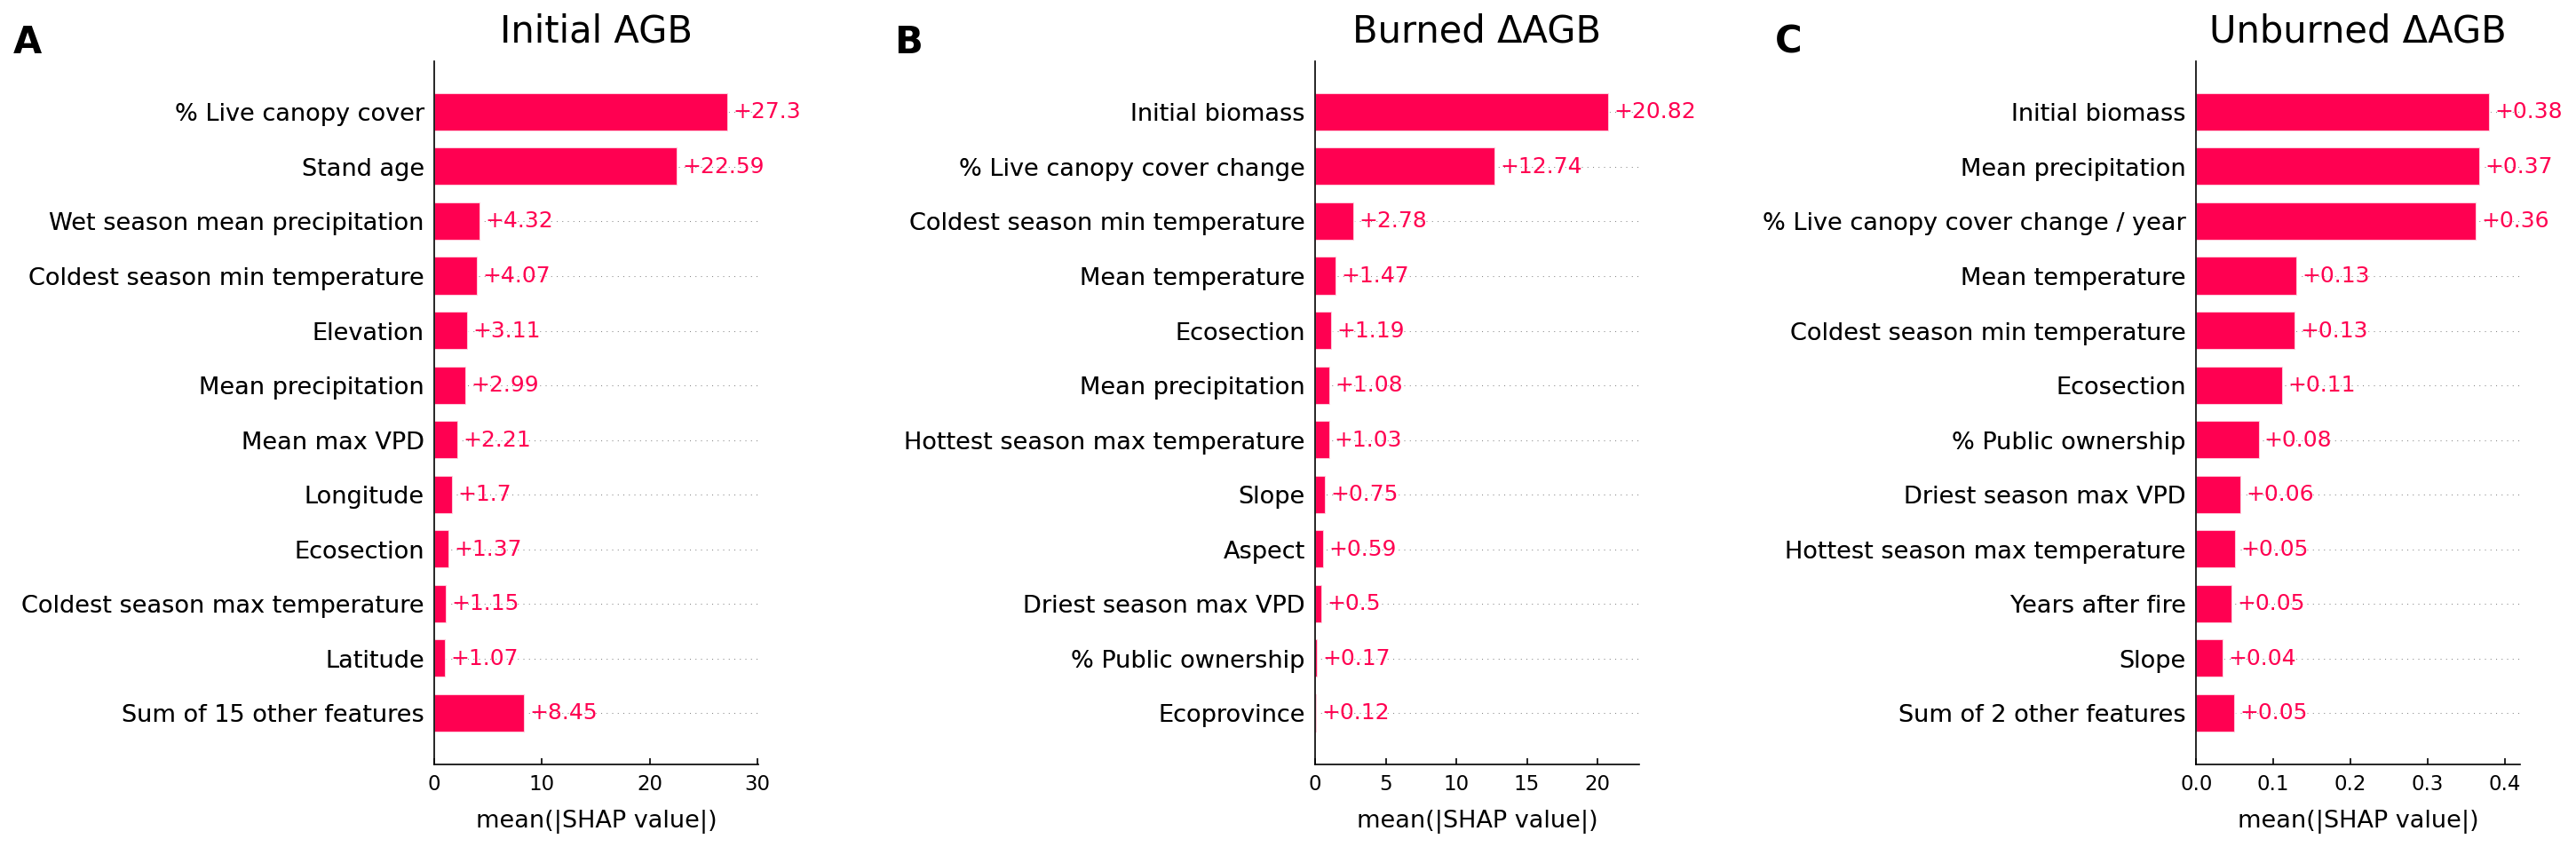

In [5]:
figure_settings.apply_style()

fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharex=False)
shap.plots.bar(shap_values_init, max_display=12, show=False, ax=axes[0])
shap.plots.bar(shap_values_burned, max_display=12, show=False, ax=axes[1])
shap.plots.bar(shap_values_undisturbed, max_display=12, show=False, ax=axes[2])

titles = ["Initial AGB", "Burned ΔAGB", "Unburned ΔAGB"]
panel_labels = ["A", "B", "C"]
for i, ax in enumerate(axes):
    ax.set_title(titles[i], fontsize=20)
    ax.text(
        -1.3,
        1.0,
        panel_labels[i],
        fontweight="bold",
        fontsize=20,
        va="bottom",
        ha="left",
        transform=ax.transAxes,
    )

plt.subplots_adjust(wspace=4)
plt.tight_layout()

plt.savefig(dir_info.dir_figures + "shap_bar_charts.png", bbox_inches="tight")
plt.show()

## Figure S-B: Partial dependency scatter plots

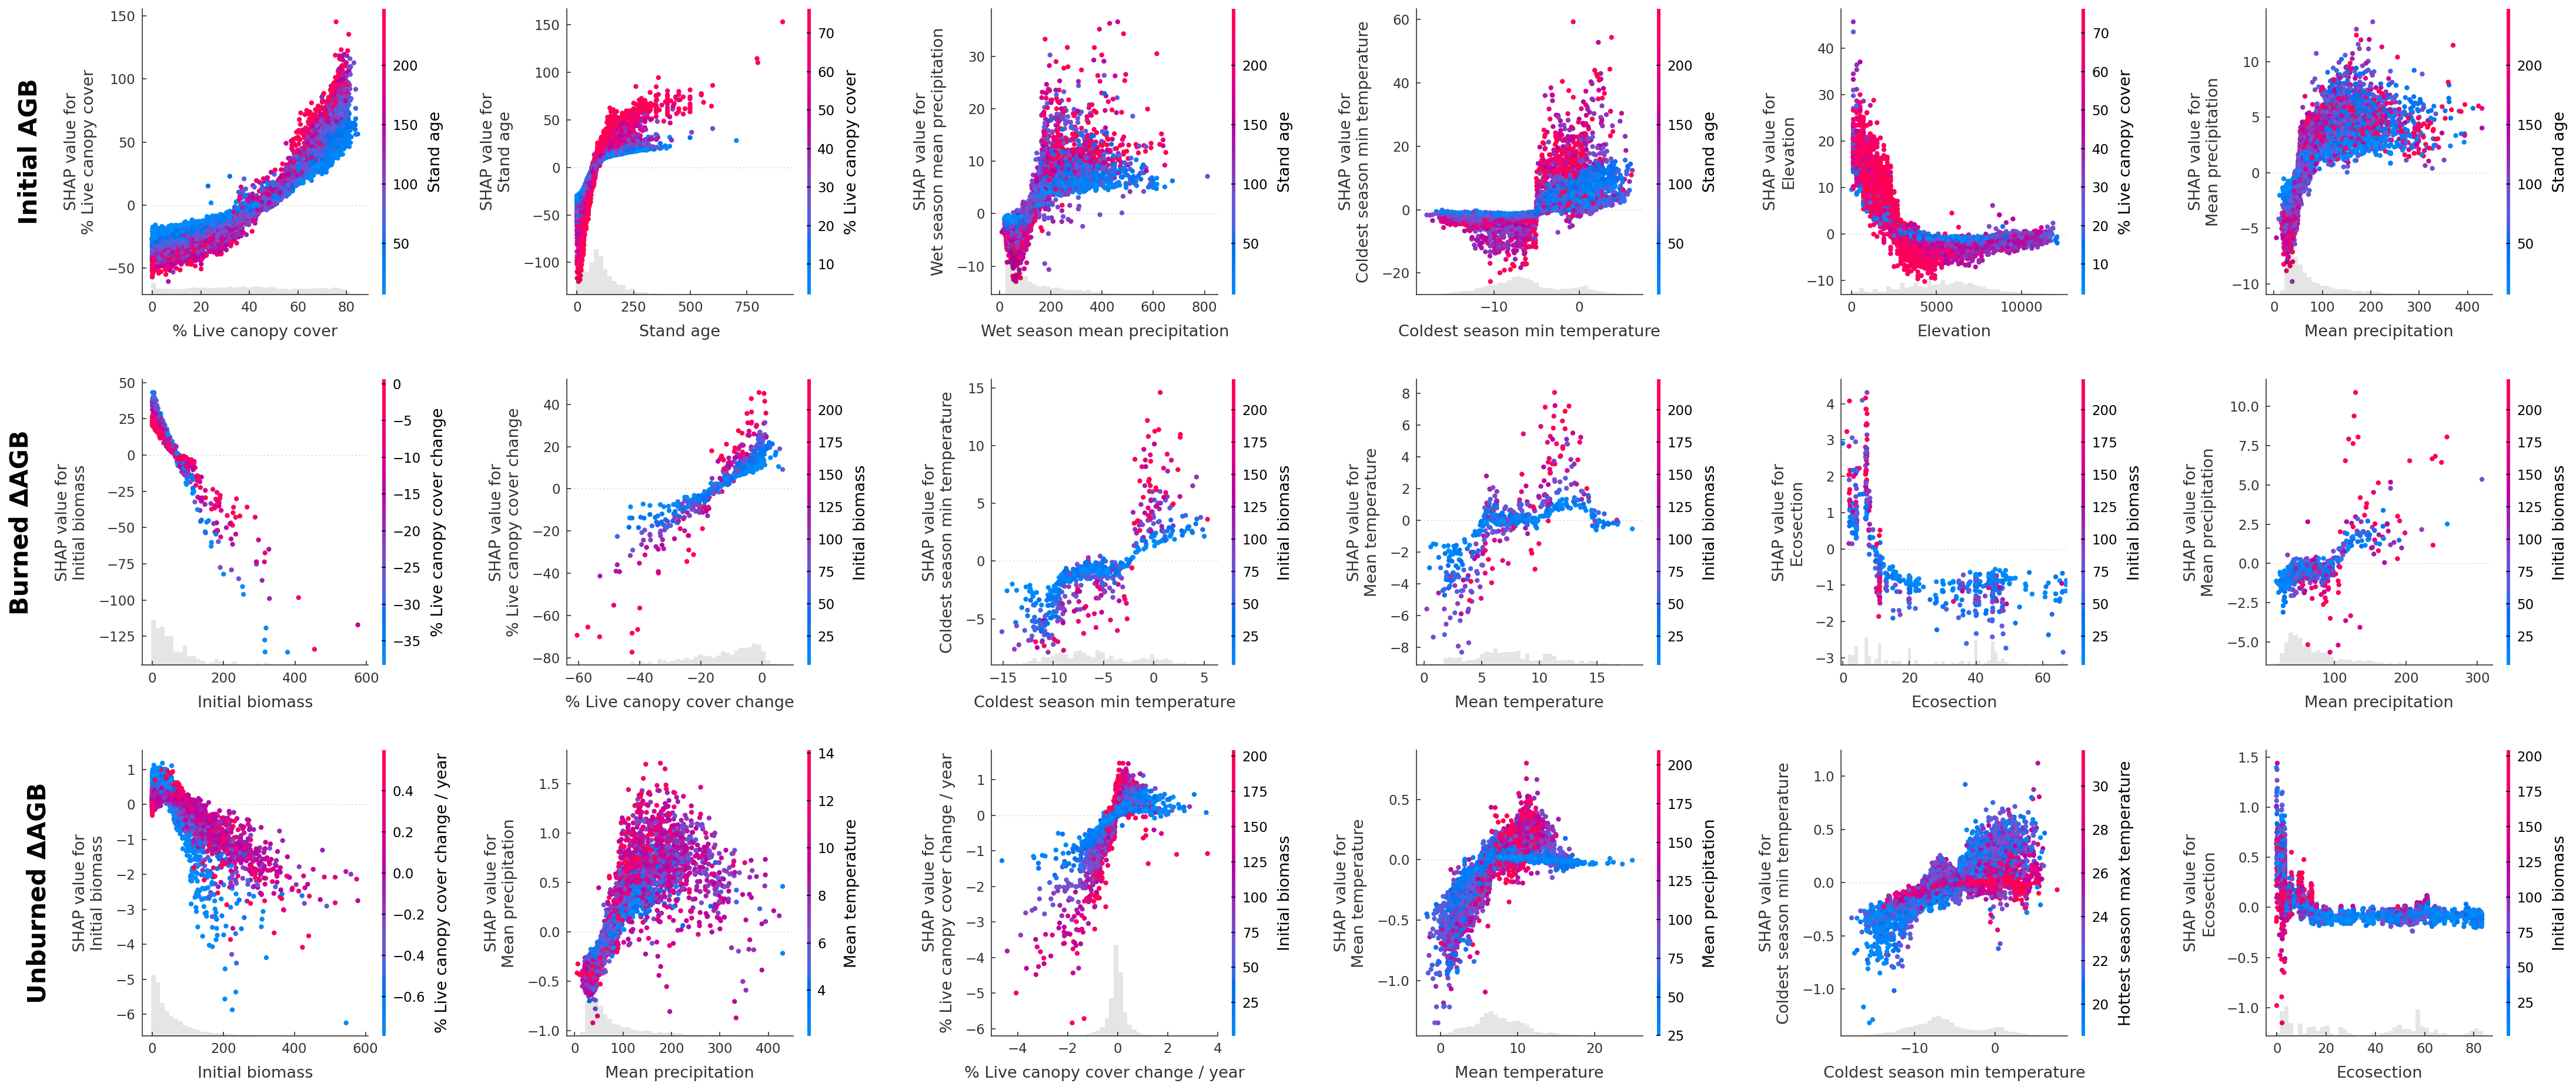

In [6]:
fig, axes = plt.subplots(nrows=3, ncols=6, figsize=(30, 13))

for plot_idx, var in enumerate(features_init):
    col_idx = list(X_test_sample_init.columns).index(var)
    shap.plots.scatter(
        shap_values_init[:, col_idx],
        ax=axes[0, plot_idx],
        show=False,
        x_jitter=0.5,
        color=shap_values_init,
    )

for plot_idx, var in enumerate(features_burned):
    col_idx = list(X_test_sample_burned.columns).index(var)
    shap.plots.scatter(
        shap_values_burned[:, col_idx],
        ax=axes[1, plot_idx],
        show=False,
        x_jitter=0.5,
        color=shap_values_burned,
    )

for plot_idx, var in enumerate(features_undisturbed):
    col_idx = list(X_test_sample_undisturbed.columns).index(var)
    shap.plots.scatter(
        shap_values_undisturbed[:, col_idx],
        ax=axes[2, plot_idx],
        show=False,
        x_jitter=0.5,
        color=shap_values_undisturbed,
    )

# Row labels on first column
row_labels = ["Initial AGB", "Burned ΔAGB", "Unburned ΔAGB"]
for row, label in enumerate(row_labels):
    axes[row, 0].annotate(
        label,
        xy=(0, 0.5),
        xytext=(-axes[row, 0].yaxis.labelpad - 10, 0),
        xycoords=axes[row, 0].yaxis.label,
        textcoords="offset points",
        fontsize=20,
        fontweight="bold",
        ha="right",
        va="center",
        rotation=90,
    )

plt.tight_layout()
plt.subplots_adjust(left=0.07)

plt.savefig(dir_info.dir_figures + "partial_dependency_plots.png", bbox_inches="tight")
plt.show()